# Fund Workstation

## Pre-Analysis Loading

#### Environment Setting

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund, merge_funds, rerun_no_perf_files, continue_running

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT CHINA','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['EUREKAHEDGE WORLD', 'MSCI CHINA',	'MSCI WORLD', 'EUREKAHEDGE ASIA', 'TOPIX', 'S&P 500', 'SOX', 'KOSPI', 'TAIEX', 'MSCI EM', 'RUSSELL 2000', 'STOXX 600', 'STOXX 50', 'FTSE UK', 'US HEALTHCARE', 'US FINANCIAL', 'US ENERGY', 'COMMODITY']

In [2]:
from dotenv import load_dotenv
load_dotenv(r"C:\Users\FOF Analyst\Desktop\fofproject\src\fofproject\.env")



True

#### Load Data via .json

In [9]:
test = load_saved_json(folder_path=r"input\marex")
funds = init_funds(test)


In [3]:
port = load_saved_json(folder_path=r"input\individual investigation")
funds = init_funds(port)


#### Load Data via .csv

In [10]:
# Use for manually update csv data of our portfolio and indices and merge with json file
portfolios = input_monthly_returns(r"RETURN DATA.csv")
funds = merge_funds(portfolios, funds)

In [12]:
# Use for manually input unparsable pdf data and merge with json file 
manual_csv = input_monthly_returns(r"MANUAL INPUTS.csv")
funds = merge_funds( manual_csv, funds)

#### GPT Input Factsheet

##### Parse Everything

In [3]:
# Do not open the pdf while running, or the renaming process will encounter error
gpt_fund = process_pdfs_in_folder(folder_path=r"input\greenwoods",save=True)
funds = init_funds(gpt_fund)

Processing: input\greenwoods\GREENWOODS HARMONY_parsed from_景林平稳基金2025年12月月报.pdf
Processing: input\greenwoods\GREENWOODS VALUE_parsed from_景林价值收益基金2025年12月月报 .pdf
Only one year 2025 found in table of GREENWOODS, returned empty list
Processing: input\greenwoods\景林环球基金2025年12月月报 .pdf
Processing: input\greenwoods\金色中国基金2025年12月月报 .pdf


##### Continue Running Unparsed

In [6]:
gpt_fund_2 = continue_running(folder_path=r"input\greenwoods",save=True)
gpt_fund_2 = init_funds(gpt_fund_2)

Processing: input\greenwoods\Frontier Road_Q4_2025_Newsletter.pdf
Only one year 2025 found in table of FRONTIER ROAD, returned empty list


In [7]:
funds = gpt_fund_2 | funds

##### Re-Run No Performance Funds

In [4]:
# Target the files with "No Performance Found", and re-run the analysis again
gpt_fund_2 = rerun_no_perf_files(folder_path=r"input\greenwoods",save=True)

Re-processing (no performance before): input\greenwoods\GREENWOODS HARMONY_parsed from_景林平稳基金2025年12月月报.pdf
Re-processing (no performance before): input\greenwoods\GREENWOODS VALUE_parsed from_景林价值收益基金2025年12月月报 .pdf
Only one year 2025 found in table of GREENWOODS, returned empty list
Re-processing (no performance before): input\greenwoods\GREENWOODS_parsed from_景林环球基金2025年12月月报 .pdf


#### Merging Different Input

In [ ]:
# Use the left hand's PERFORMANCE TABLE to update the right hand one
funds = merge_funds(portfolio_csv, funds)

In [4]:
# Right-hand side has higher priority
funds = funds | test

#### Save the Changes to .json & .csv

In [ ]:
# Careful what fund you are saving to what folder
save_changes_in_fund(funds, folder_path=r"input\worth_a_look")

In [ ]:
print(funds['ASIAN TECHNOLOGY'].total_max_dd)

## Fund Analysis

#### Dataframe Comparison

In [12]:
df = compare_funds(funds)
do_not_display = our_index + our_portfolio
df = df[~df["Name"].isin(do_not_display)].reset_index(drop=True)
print(df)


         Name                                        Description  \
0    BAY POND  BAY POND IS A FINANCIALS LONG/SHORT EQUITY STR...   
1  WELLINGTON  Wellington Strategic European Equity Long/Shor...   
2       RDGFF                                               None   

                        Location     Strategy                Sector  \
0  [north_america, europe, apac]  [equity_ls]      [equity_finance]   
1                       [europe]  [equity_ls]  [equity_diversified]   
2                           None         None                  None   

                                            Managers  \
0  Nick Adams, Matt Lipton, William Wrightson, Jo...   
1                                     Dirk Enderlein   
2                                               None   

                                             Contact  AUM (in Mn USD)  \
0   - Based in , try reachout via email '' or pho...           3200.0   
1   - Based in Boston, MA, USA, try reachout via ...           1327.0  

In [ ]:
# Column List = ["Name", "Description", "Location", "Strategy", "Sector", "Managers", "Contact", "AUM (in Mn USD)", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", "Month Running",
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]


In [ ]:
# sort by what we think important   
df = df.sort_values(by=["Sharpe Ratio", "Annualized Return"], ascending=[False, False])
# mask and filtered only the wanted funds
mask =  (df["Month Running"] > 6) & (df["Annualized Return"] > 0.12)
df['Worth a Look'] = mask
# Display only the following columns
display_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Description","Max Drawdown" ]]
display_df


#### Save it to CSV

In [ ]:
# Select the column you want to save
output_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Max Drawdown" ,"Net Exposure","Strategy", "Sector","Contact","Description", "Mgmt Fee", "Perf Fee"]]
output_df.to_csv("output/funds_comparison.csv", index=False)

#### Save it to a list

In [ ]:
exclude_list = our_index + our_portfolio
df = df[~df["Name"].isin(exclude_list)].reset_index(drop=True)
worth_looking = df.loc[df["Worth a Look"], "Name"].tolist()
print(worth_looking)

#### Compare Performance Table

In [ ]:
funds['ONELS'].export_monthly_table(benchmark_fund = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)

#### Plot Cumulative Return

In [17]:

funds_to_be_plot = subset_of_funds(funds, ['S&P 500', 'RDGFF', 'US FINANCIAL'])
start_month = "2022-12"
end_month = "2023-9"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="excel",
    language="en",
    blur=False,
    aspect_lock=True,
    custom_ticks=False,
    save=False,
    toggle=False
    )


#### Correlation Heat Map

In [ ]:
# Correlation heatmap
funds_to_be_plot = subset_of_funds(funds, ['QUANTICA', 'RDGFF', 'HAO','US FINANCIAL'])
start_month = "2019-12"
end_month = "2025-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12, save=True)
fig.show()

#### Efficient Frontier Analysis

In [18]:
remove_list = ['RDGFF', 'E20']

for i, k in enumerate(our_portfolio):
    if k in remove_list:
        our_portfolio.pop(i)
test =  ['RDGFF', 'QUANTICA']
print(our_portfolio)


funds_to_be_plot = subset_of_funds(funds, test)
print(len(funds))

['TAIREN', 'HAO', 'LEXINGTON', 'LIM', 'FOREST', 'WT CHINA', '3W GLOBAL', '3W CHINA', '3W HEALTHCARE', 'TIMEFOLIO', 'MONOLITH', 'PERSEVERANCE', 'NEO IVY', 'JH BIOTECH']
46


In [ ]:
# Choose Mode between "Maximum Sharpe", "Minimum Variance", "Target Return"
fig, weights, stats = minimum_variance_analysis(funds=funds_to_be_plot, mode="Maximum Sharpe", title=None)
print(weights)
print(stats)

#### Summary of a Fund

Frontier Road Master Fund is a long/short credit fund focused on emerging markets with a counter-cyclical investment style. It employs multiple strategies including Relative Value, Strategic, High Frequency, and Convexity, with a strong emphasis on risk-adjusted returns and dynamic net exposure management. The fund has delivered strong annualized returns since inception with a prudent approach to market volatility. Rating: 4, overall positive view.
Net Exposure = 34.0% to 34.0%
 - Based in , try reachout via email 'info@frontierroad.co.uk' or phone '+44 7501 552 939'
Chart saved to FRONTIER ROAD_vs_MSCI EM_Fund Performance on Benchmark's Worst Days.png


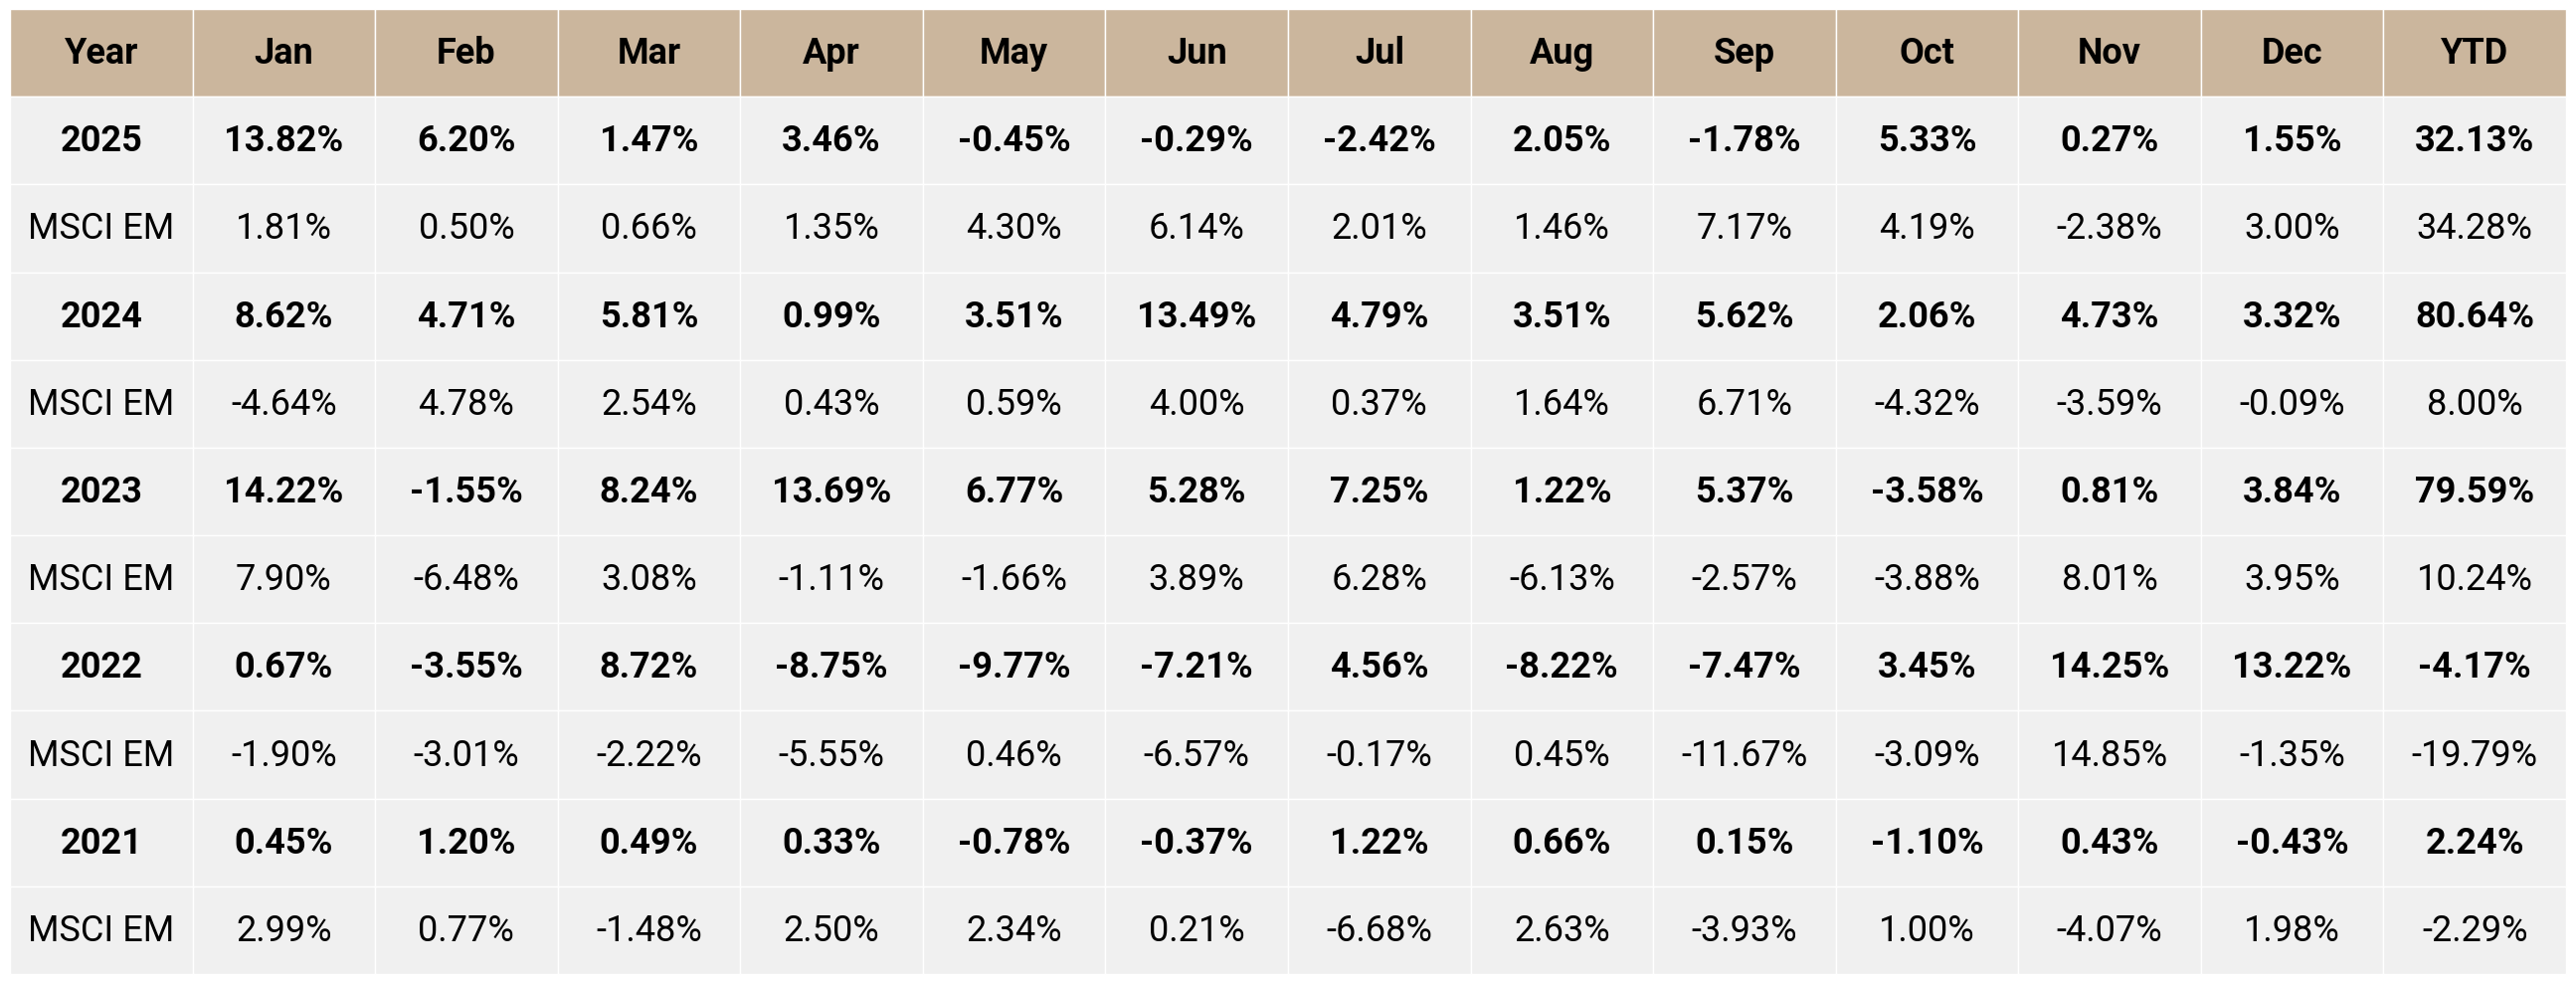

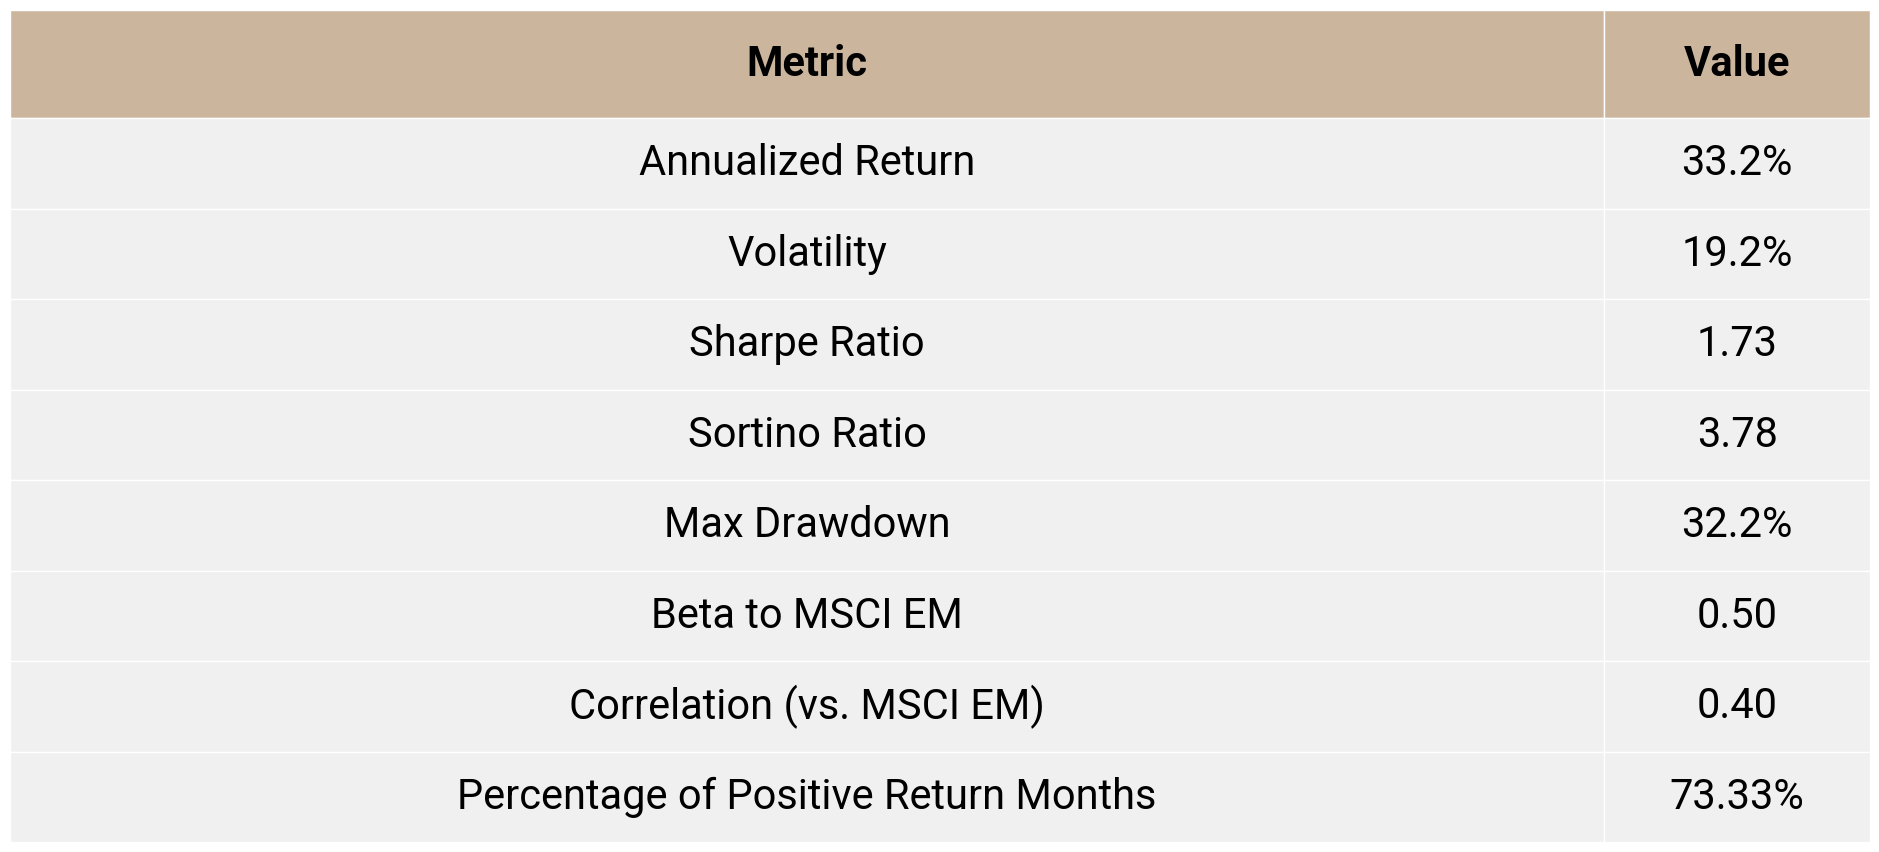

C:\Users\FOF Analyst\Desktop\fofproject\src\fofproject\fund.py:1713: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



Chart saved to FRONTIER ROAD_vs_RDGFF_Performance during our fund's top 10 drawdowns.png
Chart saved to FRONTIER ROAD_vs_RDGFF_Entire performance compared with our fund's.png


In [12]:
# our_index = ['EUREKAHEDGE WORLD', 'MSCI CHINA',	'MSCI WORLD', 'EUREKAHEDGE ASIA', 'TOPIX', 'S&P 500', 'SOX', 'KOSPI', 'TAIEX', 'MSCI EM', 'RUSSELL 2000', 'STOXX 600', 'STOXX 50', 'FTSE UK', 'US HEALTHCARE', 'US FINANCIAL', 'US ENERGY', 'COMMODITY']
fund_name = 'FRONTIER ROAD'
funds[fund_name].summary_of_a_fund(benchmark_fund=funds['MSCI EM'],language="en",save=True)
funds[fund_name].compare_worst_performance(funds['RDGFF'], title="Performance during our fund's top 10 drawdowns", n_worst=10,  save=True)
funds[fund_name].compare_worst_performance(funds['RDGFF'], title="Entire performance compared with our fund's" ,n_worst=100,  save=True)

#### Correlation Deep Dive

In [13]:
# fund_name = 'FOREST STD'
funds_to_be_plot = subset_of_funds(funds, [fund_name] + our_index)
fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12, save=True)
fig.show()

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]



fig1 = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )

fig2 = compa